# Modelo de Ising 1D Clássico — Solução Exata

Este notebook calcula, de forma exata, as propriedades termodinâmicas do modelo de Ising 1D com 10 spins e sem campo externo. O cálculo é feito somando sobre todas as $2^{10}$ configurações possíveis.

O Hamiltoniano do sistema é:

$$
H = -J \sum_{i} s_i s_{i+1} - h \sum_i s_i, \quad \text{com } s_i = \pm 1
$$

## 📐 Fórmulas termodinâmicas usadas

Para cada temperatura $T$, as quantidades foram calculadas diretamente a partir da **distribuição de Boltzmann**, somando sobre todas as $2^L$ configurações possíveis do sistema de $L = 10$ spins.

### 🔹 1. Função de partição (Z)

$$
Z = \sum_{\{s\}} e^{-\beta E(s)}, \quad \text{com } \beta = \frac{1}{k_B T}
$$

---

### 🔹 2. Energia média por spin

$$
\langle E \rangle = \frac{1}{Z} \sum_{\{s\}} E(s) \, e^{-\beta E(s)} \quad \Rightarrow \quad \frac{\langle E \rangle}{L}
$$

---

### 🔹 3. Magnetização média por spin

Como estamos interessados na **magnitude média da magnetização total**, usamos:

$$
\langle |M| \rangle = \frac{1}{Z} \sum_{\{s\}} \left| \sum_i s_i \right| \cdot e^{-\beta E(s)} \quad \Rightarrow \quad \frac{\langle |M| \rangle}{L}
$$

---

### 🔹 4. Calor específico por spin

$$
C = \frac{1}{k_B T^2} \left( \langle E^2 \rangle - \langle E \rangle^2 \right) \quad \Rightarrow \quad \frac{C}{L}
$$

---

### 🔹 5. Susceptibilidade magnética por spin

$$
\chi = \frac{1}{k_B T} \left( \langle M^2 \rangle - \langle |M| \rangle^2 \right) \quad \Rightarrow \quad \frac{\chi}{L}
$$

> Onde:
> - $E(s)$ é a energia de uma configuração $s$,
> - $M(s) = \sum_i s_i$ é a magnetização total da configuração,
> - $\beta = 1/(k_B T)$,
> - $L = 10$ é o número de spins,
> - $k_B = 1$ foi usado como unidade.

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Parâmetros do modelo
L = 16            # número de spins
J = 1.0           # constante de acoplamento
h = 0.0           # campo externo
k_B = 1.0         # constante de Boltzmann
T_vals = np.linspace(0.5, 5.0, 50)  # faixa de temperaturas

# Geração de todas as 2^L configurações possíveis de spins ±1
def gerar_configuracoes(L):
    return np.array([[(x >> i) & 1 for i in range(L)] for x in range(2**L)]) * 2 - 1

# Energia de uma configuração
def energia(config, J, h):
    E = -J * np.sum(config * np.roll(config, -1)) - h * np.sum(config)
    return E

# Cálculo da função de partição e observáveis
def calcular_observaveis(L, J, h, T_vals):
    configuracoes = gerar_configuracoes(L)
    energias = np.array([energia(config, J, h) for config in configuracoes])
    magnetizacoes = np.array([np.sum(config) for config in configuracoes])

    E_medio, M_medio, C, chi = [], [], [], []

    for T in T_vals:
        pesos = np.exp(-energias / (k_B * T))
        Z = np.sum(pesos)
        E_T = np.sum(energias * pesos) / Z
        M_T = np.sum(np.abs(magnetizacoes) * pesos) / Z
        E2_T = np.sum(energias**2 * pesos) / Z
        M2_T = np.sum(magnetizacoes**2 * pesos) / Z

        C_T = (E2_T - E_T**2) / (k_B * T**2)
        chi_T = (M2_T - M_T**2) / (k_B * T)

        E_medio.append(E_T / L)
        M_medio.append(M_T / L)
        C.append(C_T / L)
        chi.append(chi_T / L)

    return E_medio, M_medio, C, chi

# Executar simulação
E, M, C, chi = calcular_observaveis(L, J, h, T_vals)

## 📊 Gráficos dos observáveis termodinâmicos

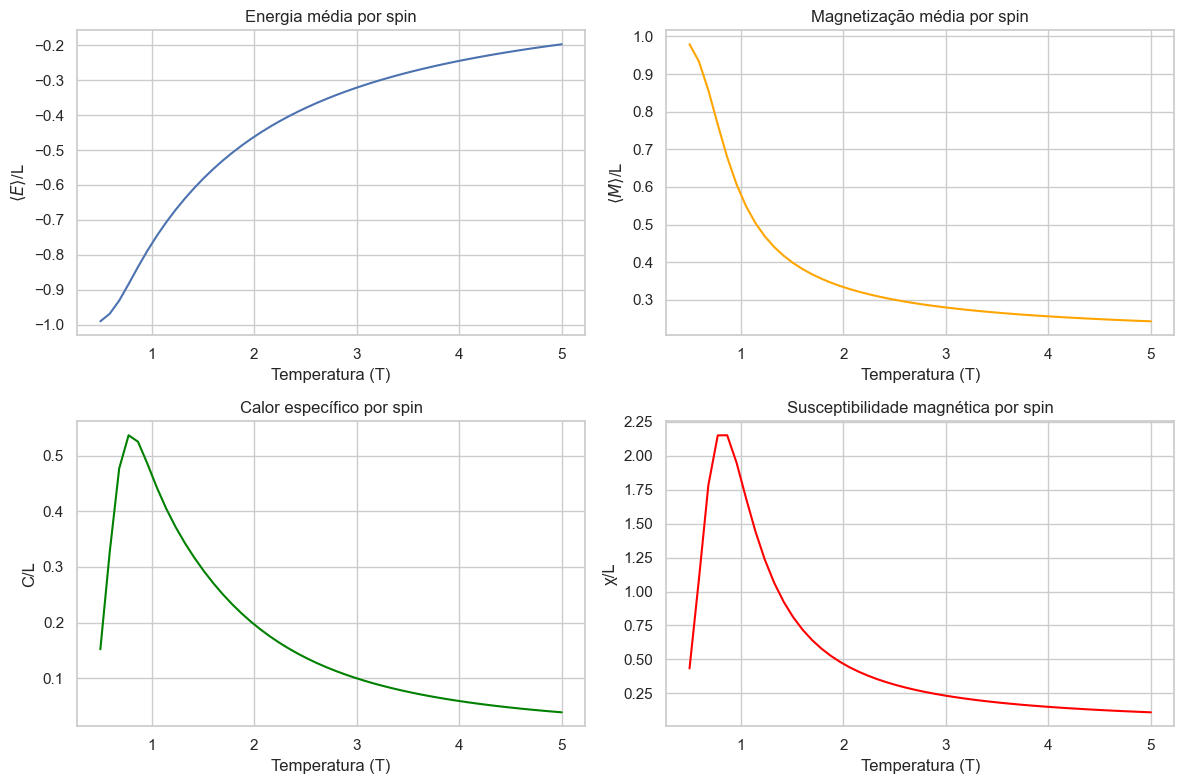

In [11]:
import matplotlib.pyplot as plt
plt.rcParams["font.family"] = "STIXGeneral"  # ou "STIXGeneral", "Computer Modern"
sns.set(style="whitegrid")
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.plot(T_vals, E, label='Energia média')
plt.xlabel('Temperatura (T)')
plt.ylabel(r"$\langle E \rangle$/L")
plt.title('Energia média por spin')

plt.subplot(2, 2, 2)
plt.plot(T_vals, M, label='Magnetização média', color='orange')
plt.xlabel('Temperatura (T)')
plt.ylabel(r"$\langle M \rangle$/L")
plt.title('Magnetização média por spin')

plt.subplot(2, 2, 3)
plt.plot(T_vals, C, label='Calor específico', color='green')
plt.xlabel('Temperatura (T)')
plt.ylabel('C/L')
plt.title('Calor específico por spin')

plt.subplot(2, 2, 4)
plt.plot(T_vals, chi, label='Susceptibilidade', color='red')
plt.xlabel('Temperatura (T)')
plt.ylabel('χ/L')
plt.title('Susceptibilidade magnética por spin')

plt.tight_layout()
plt.show()

### Animacao

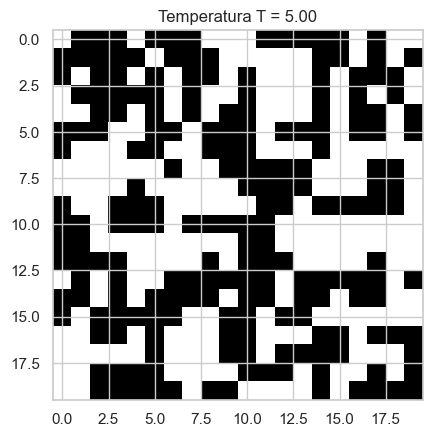

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

# Parâmetros
L = 20                     # Lado da rede LxL
temps = np.linspace(5, 0.1, 100)  # Temperatura decrescendo
J = 1                     # Acoplamento

# Inicializa spins aleatórios (+1 ou -1)
spins = np.random.choice([-1, 1], size=(L, L))

def energia_local(spins, i, j):
    """Calcula energia local do spin (i,j) com vizinhos"""
    cima = spins[(i-1)%L, j]
    baixo = spins[(i+1)%L, j]
    esq = spins[i, (j-1)%L]
    dir = spins[i, (j+1)%L]
    return -J * spins[i, j] * (cima + baixo + esq + dir)

def metropolis(spins, T):
    """Um passo de Monte Carlo usando o algoritmo de Metropolis"""
    for _ in range(L*L):
        i = np.random.randint(0, L)
        j = np.random.randint(0, L)
        dE = -2 * energia_local(spins, i, j)
        if dE < 0 or np.random.rand() < np.exp(-dE / T):
            spins[i, j] *= -1
    return spins

# Animação
fig, ax = plt.subplots()
im = ax.imshow(spins, cmap='gray', vmin=-1, vmax=1)
ax.set_title('Resfriamento do modelo de Ising')

def update(frame):
    global spins
    T = temps[frame]
    spins = metropolis(spins, T)
    im.set_array(spins)
    ax.set_title(f"Temperatura T = {T:.2f}")
    return [im]

ani = animation.FuncAnimation(fig, update, frames=len(temps), interval=100, blit=True)
plt.show()

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider
from IPython.display import display

# Tamanho da rede
L = 10
J = 1

# Inicializa spins aleatórios
spins = np.random.choice([-1, 1], size=(L, L))

def energia_local(spins, i, j):
    cima = spins[(i-1)%L, j]
    baixo = spins[(i+1)%L, j]
    esq = spins[i, (j-1)%L]
    dir = spins[i, (j+1)%L]
    return -J * spins[i, j] * (cima + baixo + esq + dir)

def metropolis_step(spins, T):
    for _ in range(L*L):
        i = np.random.randint(0, L)
        j = np.random.randint(0, L)
        dE = -2 * energia_local(spins, i, j)
        if dE < 0 or np.random.rand() < np.exp(-dE / T):
            spins[i, j] *= -1
    return spins



In [18]:
def plot_spins(T):
    global spins
    spins = metropolis_step(spins, T)
    fig, ax = plt.subplots(figsize=(5, 5))
    ax.set_title(f"Modelo de Ising — Temperatura T = {T:.2f}")
    ax.set_xlim(-1, L)
    ax.set_ylim(-1, L)
    ax.set_aspect('equal')
    ax.axis('off')

    # Cria vetores
    X, Y = np.meshgrid(np.arange(L), np.arange(L))
    U = np.zeros((L, L))       # componente x
    V = spins                  # componente y (+1 ou -1)

    ax.quiver(X, Y, U, V, scale=1, scale_units='xy', angles='xy', color='blue')
    plt.show()

# Slider interativo
slider = FloatSlider(value=5.0, min=0.1, max=5.0, step=0.1, description='Temperatura')
interact(plot_spins, T=slider);

interactive(children=(FloatSlider(value=5.0, description='Temperatura', max=5.0, min=0.1), Output()), _dom_cla…

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider

# Tamanho da cadeia 1D
L = 100

# Inicializa spins aleatoriamente: +1 ou -1
spins = np.random.choice([-1, 1], size=L)

# Função de atualização dos spins (Metropolis simplificado para 1D)
def metropolis_step(spins, T):
    for _ in range(L):
        i = np.random.randint(0, L)
        s = spins[i]
        vizinhos = spins[(i+1)%L] + spins[(i-1)%L]
        dE = 2 * s * vizinhos
        if dE < 0 or np.random.rand() < np.exp(-dE / T):
            spins[i] *= -1
    return spins

# Função de plotagem com spins em linha
def plot_spins(T):
    global spins
    spins = metropolis_step(spins, T)
    
    fig, ax = plt.subplots(figsize=(12, 2))
    ax.set_title(f"Modelo de Ising 1D — Temperatura T = {T:.2f}")
    ax.set_xlim(-1, L)
    ax.set_ylim(-5, 5)
    ax.set_aspect('equal')
    ax.axis('off')

    X = np.arange(L)
    Y = np.zeros(L)
    U = np.zeros(L)
    V = 5 * spins

    ax.quiver(X, Y, U, V, angles='xy', scale=1, scale_units='xy', width=0.01, color='blue')
    plt.show()

# Slider de temperatura interativo
interact(plot_spins, T=FloatSlider(value=5.0, min=0.0000000000000000001, max=15.0, step=0.1, description='Temperatura'));

interactive(children=(FloatSlider(value=5.0, description='Temperatura', max=15.0, min=1e-19), Output()), _dom_…